Total frames     : 3864
Valid detections : 3504  (90.7% of frames)
Time span        : 0.000 s → 77.260 s
theta range      : -3.1290 to 3.1322 rad



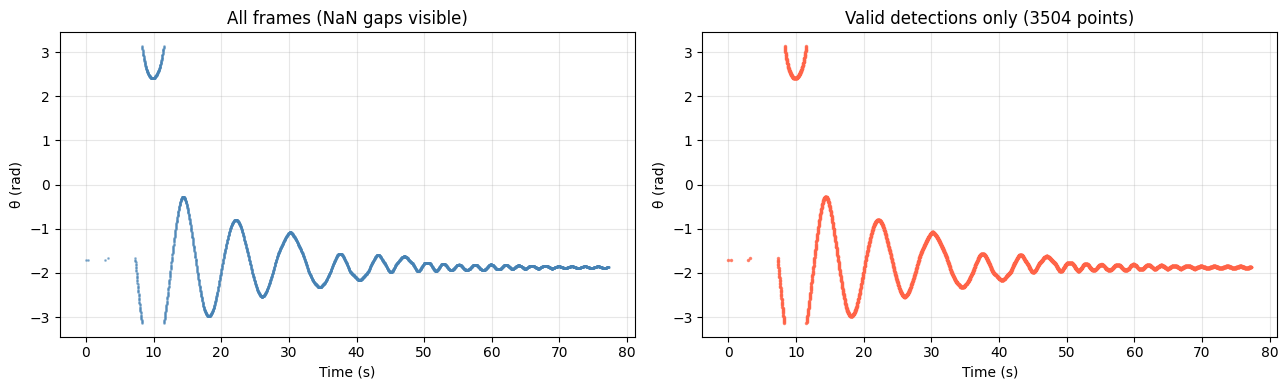

Diagnostic plot saved → signal_diagnostic.png
Spiral starts at index 4  |  t = 7.280 s  |  θ = 0.2059 rad
Points in spiral: 3500

Rough period estimate: 1.8000 s  |  min_dist = 54 samples
Step 1 → 31 peaks detected

Step 2 → Fit: A₀ = 2.06392 ± 5.34e-02,  t_e = 15.51684 ± 5.50e-01 s
Step 3 → T = 2.22533 ± 1.10e+00 s  |  ω_res = 2.8235 rad/s  |  f = 0.4494 Hz

Step 4 → α = 0.022825 ± 1.13e-02
Step 5 → γ = 0.000000 ± 2.97e-10

  FINAL:  γ = 0.0000 ± 2.97e-10   (I = 4.6515225881017465e-09)


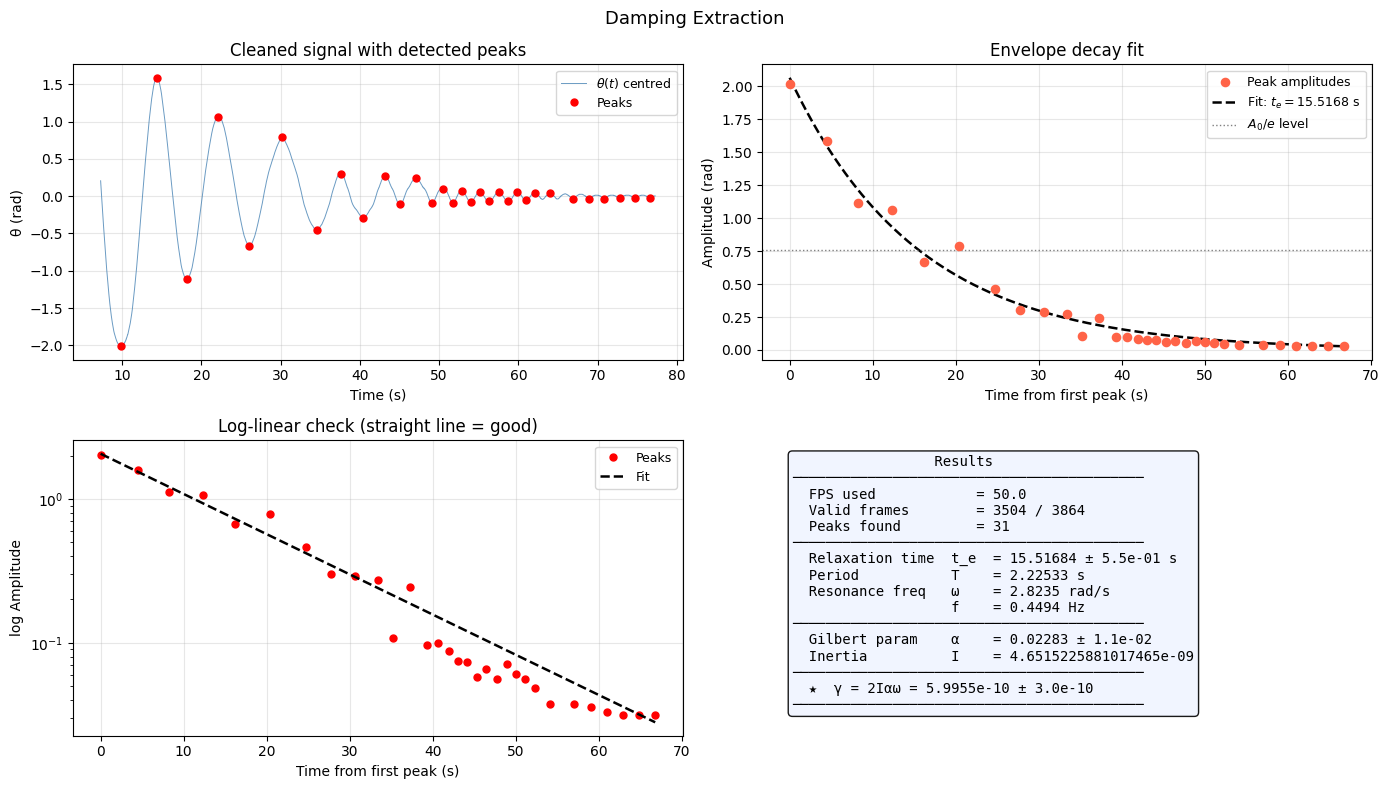

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.optimize import curve_fit

df = pd.read_csv('tracking_output_6.csv')
FPS = 50
df['time_s'] = df['frame'] / FPS

# Drop rows where theta_rad was not detected (NaN)
df_clean = df[['time_s', 'theta_rad']].dropna(subset=['theta_rad']).copy()
df_clean = df_clean.sort_values('time_s').reset_index(drop=True)

t     = df_clean['time_s'].values
theta = df_clean['theta_rad'].values

print(f"Total frames     : {len(df)}")
print(f"Valid detections : {len(df_clean)}  ({100*len(df_clean)/len(df):.1f}% of frames)")
print(f"Time span        : {t[0]:.3f} s → {t[-1]:.3f} s")
print(f"theta range      : {theta.min():.4f} to {theta.max():.4f} rad\n")

if len(df_clean) < 10:
    print("⚠  Very few valid frames. The tracker struggled to detect the marker.")
    print("   Consider re-running tracking with adjusted blob/threshold params.")

# ─────────────────────────────────────────────────────────────
#  DIAGNOSTIC PLOT — see what the cleaned signal looks like
# ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(df['time_s'], df['theta_rad'], '.', ms=2, color='steelblue', alpha=0.5)
axes[0].set_title('All frames (NaN gaps visible)')
axes[0].set_xlabel('Time (s)'); axes[0].set_ylabel('θ (rad)')
axes[0].grid(True, alpha=0.3)

axes[1].plot(t, theta, '.', ms=3, color='tomato', alpha=0.7)
axes[1].set_title(f'Valid detections only ({len(df_clean)} points)')
axes[1].set_xlabel('Time (s)'); axes[1].set_ylabel('θ (rad)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('signal_diagnostic.png', dpi=150, bbox_inches='tight')
plt.show()
print("Diagnostic plot saved → signal_diagnostic.png")

# ─────────────────────────────────────────────────────────────
#  1. UNWRAP theta if it wraps around ±π, then centre on 0
# at turning point: theta = theta, omega = 0
# ─────────────────────────────────────────────────────────────
theta_unwrap = np.unwrap(theta)
theta_centred = theta_unwrap - np.median(theta_unwrap)   # centre around equilibrium
dt_raw   = np.diff(t)
omega_raw = np.diff(theta_centred) / dt_raw

# First zero-crossing of omega = start of oscillation
zc = np.where(np.diff(np.sign(omega_raw)))[0]

if len(zc) > 0:
    spiral_start = zc[0] + 1          # +1 because diff shifts index by 1
else:
    spiral_start = 0                   # fallback: use all data
    print("⚠  No zero-crossing found — using full dataset")

# Trim
t             = t[spiral_start:]
theta_centred = theta_centred[spiral_start:]
print(f"Spiral starts at index {spiral_start}  |  t = {t[0]:.3f} s  |  θ = {theta_centred[0]:.4f} rad")
print(f"Points in spiral: {len(t)}\n")

theta_abs = np.abs(theta_centred)

# ─────────────────────────────────────────────────────────────
#  2. ADAPTIVE PEAK DETECTION
# ─────────────────────────────────────────────────────────────
# Estimate a rough period from zero-crossings
signs = np.sign(theta_centred)
zc_idx = np.where(np.diff(signs) != 0)[0]
# linear interpolation for sub-sample zero-crossing times
t_zero = t[zc_idx] + dt_raw[zc_idx] * (
    -theta_centred[zc_idx] / (theta_centred[zc_idx + 1] - theta_centred[zc_idx])
)
# then use t_zero instead of t[zero_cross_idx]:
half_periods = np.diff(t_zero)
T_rough = 2.0 * np.median(half_periods)

if len(t_zero) >= 4:
    half_periods = np.diff(t_zero)
    T_rough = 2.0 * np.median(half_periods)
    dt_median = np.median(np.diff(t))               # median time step (uneven gaps!)
    min_dist = max(int(0.6 * T_rough / dt_median), 2)
    print(f"Rough period estimate: {T_rough:.4f} s  |  min_dist = {min_dist} samples")
else:
    min_dist = max(len(t) // 20, 2)
    T_rough = None
    print(f"⚠  Few zero-crossings found. Using min_dist = {min_dist}")

#peak detection
peaks_idx, _ = find_peaks(
    theta_abs,
    distance=min_dist,
    height=np.percentile(theta_abs[theta_abs > 0], 10)   # bottom quartile cutoff
)

# ADD this block after find_peaks:
t_peaks_interp = np.zeros(len(peaks_idx), dtype=float)
A_peaks_interp = np.zeros(len(peaks_idx), dtype=float)

for j, idx in enumerate(peaks_idx):
    if idx == 0 or idx == len(theta_abs) - 1:
        t_peaks_interp[j] = t[idx]
        A_peaks_interp[j] = theta_abs[idx]
    else:
        # fit parabola to 3 points around peak
        y0, y1, y2 = theta_abs[idx-1], theta_abs[idx], theta_abs[idx+1]
        t0_, t1_, t2_ = t[idx-1], t[idx], t[idx+1]
        # quadratic peak location
        denom = (y0 - 2*y1 + y2)
        if denom != 0:
            dt_offset = 0.5 * (y0 - y2) / (2 * denom) * (t2_ - t0_)
        else:
            dt_offset = 0
        t_peaks_interp[j] = t[idx] + dt_offset
        A_peaks_interp[j] = y1 - (y0 - y2)**2 / (8 * denom) if denom != 0 else y1

# use these instead:
t_peaks = t_peaks_interp
A_peaks = A_peaks_interp

print(f"Step 1 → {len(peaks_idx)} peaks detected\n")

if len(peaks_idx) < 4:
    print("⚠  Still too few peaks after cleaning.")
    print("   Possible causes:")
    print("   - Wrong FPS value (change FPS above)")
    print("   - Signal is not oscillating (check diagnostic plot)")
    print("   - Tracking gaps too large (need re-tracking with lower threshold)")
    raise SystemExit("Not enough data for damping fit.")

# ─────────────────────────────────────────────────────────────
#  3. EXPONENTIAL DECAY FIT  A(t) = A0 * exp(-t / t_e)
# ─────────────────────────────────────────────────────────────
def exp_decay(t, A0, t_e):
    return A0 * np.exp(-t / t_e)

t0 = t_peaks[0]
try:
    popt, pcov = curve_fit(
        exp_decay,
        t_peaks - t0,
        A_peaks,
        p0=[A_peaks[0], (t_peaks[-1] - t0) / 2.0],
        bounds=([0, 1e-9], [np.inf, np.inf]),
        maxfev=10000
    )
    A0_fit, t_e = popt
    A0_err, te_err = np.sqrt(np.diag(pcov))
    print(f"Step 2 → Fit: A₀ = {A0_fit:.5f} ± {A0_err:.2e},  t_e = {t_e:.5f} ± {te_err:.2e} s")
except RuntimeError as e:
    print(f"Fit failed: {e}")
    raise

# ─────────────────────────────────────────────────────────────
#  4. RESONANCE FREQUENCY
# ─────────────────────────────────────────────────────────────
T_avg     = np.mean(np.diff(t_peaks))
T_std     = np.std(np.diff(t_peaks))
omega_res = 2.0 * np.pi / T_avg
f_res     = 1.0 / T_avg

print(f"Step 3 → T = {T_avg:.5f} ± {T_std:.2e} s  |  ω_res = {omega_res:.4f} rad/s  |  f = {f_res:.4f} Hz")

# ─────────────────────────────────────────────────────────────
#  5. GILBERT α  &  VISCOUS γ
# ─────────────────────────────────────────────────────────────
rho = 2070
m = rho * np.pi * (1.1e-3) * ((7.8e-3)**2 - (7.0e-3)**2)
I = 0.5 * m * ((7.8e-3)**2 + (7.0e-3)**2)
alpha = 1 / (omega_res * t_e)
alpha_err = alpha * np.sqrt((te_err/t_e)**2 + (T_std/T_avg)**2)

gamma = 2.0 * I * alpha * omega_res
gamma_err = 2.0 * I * alpha_err * omega_res

print(f"\nStep 4 → α = {alpha:.6f} ± {alpha_err:.2e}")
print(f"Step 5 → γ = {gamma:.6f} ± {gamma_err:.2e}")
print(f"\n{'='*50}")
print(f"  FINAL:  γ = {gamma:.4f} ± {gamma_err:.2e}   (I = {I})")
print(f"{'='*50}")

# ─────────────────────────────────────────────────────────────
#  FINAL FIGURE
# ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle(r'Damping Extraction', fontsize=13)

t_fit_arr = np.linspace(0, t_peaks[-1] - t0, 400)
A_fit_arr = exp_decay(t_fit_arr, A0_fit, t_e)

ax = axes[0, 0]
ax.plot(t, theta_centred, lw=0.7, color='steelblue', alpha=0.8, label=r'$\theta(t)$ centred')
ax.plot(t[peaks_idx], theta_centred[peaks_idx], 'ro', ms=5, label='Peaks')
ax.set_xlabel('Time (s)'); ax.set_ylabel('θ (rad)')
ax.set_title('Cleaned signal with detected peaks'); ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

ax = axes[0, 1]
ax.scatter(t_peaks - t0, A_peaks, color='tomato', s=35, zorder=5, label='Peak amplitudes')
ax.plot(t_fit_arr, A_fit_arr, 'k--', lw=1.8, label=fr'Fit: $t_e={t_e:.4f}$ s')
ax.axhline(A0_fit / np.e, color='gray', ls=':', lw=1, label='$A_0/e$ level')
ax.set_xlabel('Time from first peak (s)'); ax.set_ylabel('Amplitude (rad)')
ax.set_title('Envelope decay fit'); ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

ax = axes[1, 0]
ax.semilogy(t_peaks - t0, A_peaks, 'ro', ms=5, label='Peaks')
ax.semilogy(t_fit_arr, A_fit_arr, 'k--', lw=1.8, label='Fit')
ax.set_xlabel('Time from first peak (s)'); ax.set_ylabel('log Amplitude')
ax.set_title('Log-linear check (straight line = good)'); ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

ax = axes[1, 1]
ax.axis('off')
summary = (
    f"{'Results':^42}\n{'─'*42}\n"
    f"  FPS used            = {FPS:.1f}\n"
    f"  Valid frames        = {len(df_clean)} / {len(df)}\n"
    f"  Peaks found         = {len(peaks_idx)}\n"
    f"{'─'*42}\n"
    f"  Relaxation time  t_e  = {t_e:.5f} ± {te_err:.1e} s\n"
    f"  Period           T    = {T_avg:.5f} s\n"
    f"  Resonance freq   ω    = {omega_res:.4f} rad/s\n"
    f"                   f    = {f_res:.4f} Hz\n"
    f"{'─'*42}\n"
    f"  Gilbert param    α    = {alpha:.5f} ± {alpha_err:.1e}\n"
    f"  Inertia          I    = {I}\n"
    f"{'─'*42}\n"
    f"  ★  γ = 2Iαω = {gamma:.4e} ± {gamma_err:.1e}\n"
    f"{'─'*42}"
)
ax.text(0.05, 0.95, summary, transform=ax.transAxes, fontsize=10,
        va='top', fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor='#f0f4ff', alpha=0.9))

plt.tight_layout()
plt.show()



Arrays ready for U_mag cell: tv, thv, omega_s, alpha_s — all spiral-only (3496 points)


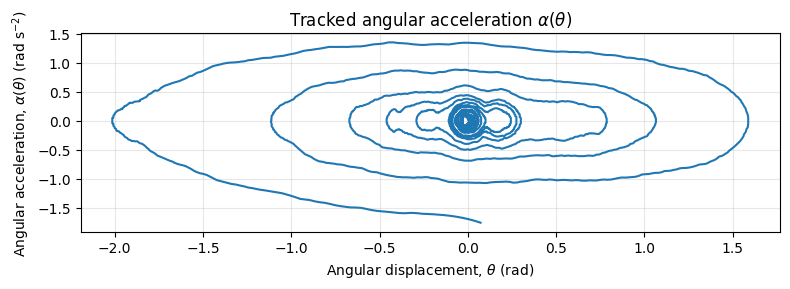

In [ ]:
from scipy.signal import savgol_filter

# Trim
t             = t[spiral_start:]
theta_centred = theta_centred[spiral_start:]

valid  = np.isfinite(theta_centred) & np.isfinite(t)
tv     = t[valid]
thv    = theta_centred[valid]

omega       = np.gradient(thv, tv)
omega_s     = savgol_filter(omega, window_length=21, polyorder=3)
alpha_raw   = np.gradient(omega_s, tv)
alpha_s     = savgol_filter(alpha_raw, window_length=21, polyorder=3)

print(f"\nArrays ready for U_mag cell: tv, thv, omega_s, alpha_s — all spiral-only ({len(tv)} points)")
plt.figure(figsize=(8, 3))
plt.plot(thv, omega_s, lw=1.5)
plt.xlabel(r'Angular displacement, $\theta$ (rad)')
plt.ylabel(r'Angular acceleration, $\alpha(\theta)$ (rad s$^{-2}$)')
plt.title(r'Tracked angular acceleration $\alpha(\theta)$')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('Alpha(t) vs theta.png', dpi=400, bbox_inches='tight')
plt.show()

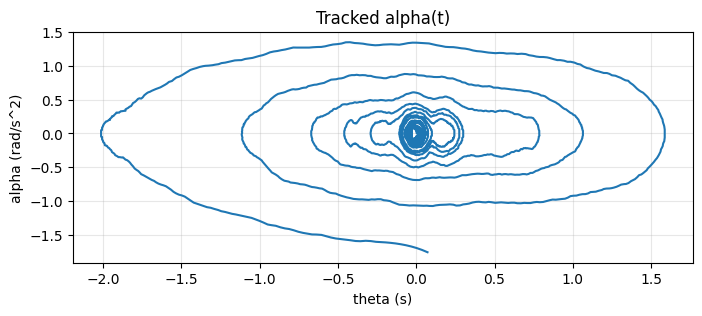

In [ ]:
plt.figure(figsize=(8,3))
plt.plot(thv, omega_s, lw=1.5)
plt.xlabel("theta (s)")
plt.ylabel("alpha (rad/s^2)")
plt.title("Tracked alpha(t)")
plt.grid(True, alpha=0.3)
plt.show()

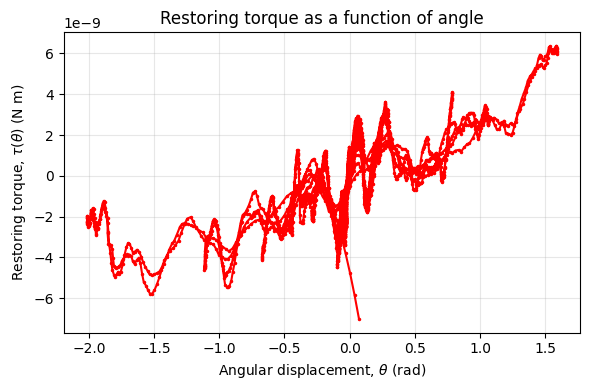

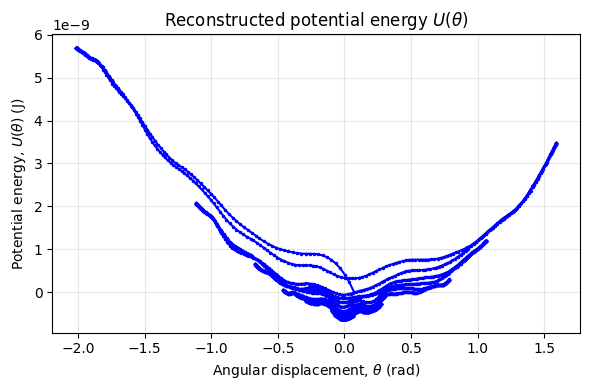

In [ ]:
from scipy.integrate import cumulative_trapezoid
## Culmulative trapezoid
# tv, thv, alpha come from the valid segment
# tv: time, thv: continuous theta_cont[valid], alpha: from omega_s on tv

rho = 2070
m = rho * np.pi * (1.1e-3) * ((7.8e-3)**2 - (7.0e-3)**2)
I = 0.5 * m * ((7.8e-3)**2 + (7.0e-3)**2)

tau_inst = I * alpha_s
tau_diss = gamma * omega_s
tau_total = - (tau_inst + tau_diss)


# U_mag(theta) from torque:  U = -∫ tau dθ
##### this is the delta_Umag, so need to add together
U_theta = cumulative_trapezoid(tau_total, thv, initial=0)

# --- 1) Restoring torque vs angle ---

plt.figure(figsize=(6, 4))
plt.plot(thv, tau_total, 'r.-', ms=3)
plt.title(r'Restoring torque as a function of angle')
plt.xlabel(r'Angular displacement, $\theta$ (rad)')
plt.ylabel(r'Restoring torque, $\tau(\theta)$ (N m)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('restoring_torque_vs_angle.png', dpi=400, bbox_inches='tight')

# --- 2) Reconstructed potential vs angle ---

plt.figure(figsize=(6, 4))
plt.plot(thv, U_theta, 'b.-', ms=3)
plt.title(r'Reconstructed potential energy $U(\theta)$')
plt.xlabel(r'Angular displacement, $\theta$ (rad)')
plt.ylabel(r'Potential energy, $U(\theta)$ (J)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('reconstructed_potential_vs_angle.png', dpi=400, bbox_inches='tight')

plt.show()



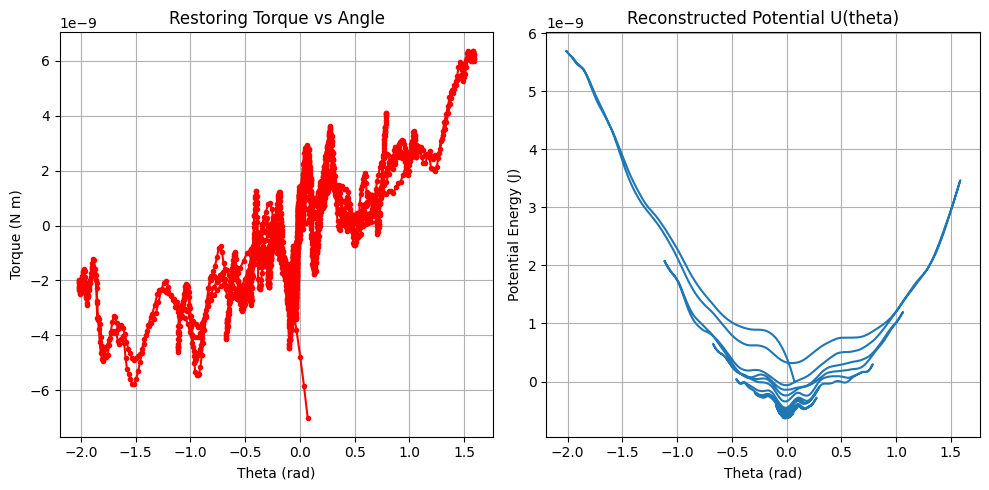

In [ ]:
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(thv, tau_total, 'r.-')
plt.title("Restoring Torque vs Angle")
plt.xlabel("Theta (rad)")
plt.ylabel("Torque (N m)")
plt.grid(True)
plt.subplot(1, 2, 2)
plt.plot(thv, U_theta, '-')
plt.title("Reconstructed Potential U(theta)")
plt.xlabel("Theta (rad)")
plt.ylabel("Potential Energy (J)")
plt.grid(True)
plt.tight_layout()
#plt.savefig(".png", dpi=400, bbox_inches="tight")
plt.show()

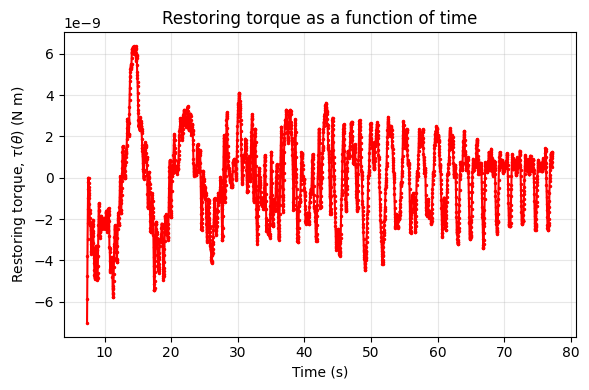

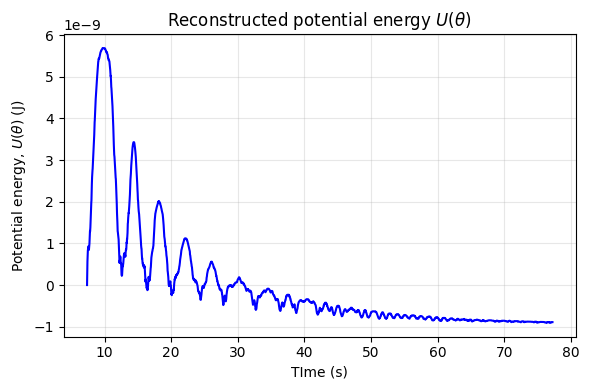

In [ ]:
# tv, thv, alpha come from the valid segment
# tv: time, thv: continuous theta_cont[valid], alpha: from omega_s on tv

rho = 2070
m = rho * np.pi * (1.1e-3) * ((7.8e-3)**2 - (7.0e-3)**2)
I = 0.5 * m * ((7.8e-3)**2 + (7.0e-3)**2)

tau_inst = I * alpha_s
tau_diss = gamma * omega_s
tau_total = - (tau_inst + tau_diss)

dt = np.diff(tv)

theta_mid = (thv[:-1] + thv[1:]) / 2
omega_mid = np.diff(thv) / dt
alpha_mid = np.diff(omega_s) / dt

tau_inst_mid  = I * alpha_mid
tau_diss_mid  = gamma * omega_mid
tau_total_mid = -(tau_inst_mid + tau_diss_mid)

d_theta = np.diff(thv)
delta_U = tau_total_mid * d_theta
U_theta = np.cumsum(np.insert(delta_U, 0, 0))

# --- 1) Restoring torque vs angle ---

plt.figure(figsize=(6, 4))
plt.plot(tv, tau_total, 'r.-', ms=3)
plt.title(r'Restoring torque as a function of time')
plt.xlabel(r'Time (s)')
plt.ylabel(r'Restoring torque, $\tau(\theta)$ (N m)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('restoring_torque_vs_time.png', dpi=400, bbox_inches='tight')

# --- 2) Reconstructed potential vs angle (NOT time) ---

plt.figure(figsize=(6, 4))
plt.plot(tv, U_theta, 'b-')
plt.title(r'Reconstructed potential energy $U(\theta)$')
plt.xlabel(r'TIme (s)')
plt.ylabel(r'Potential energy, $U(\theta)$ (J)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('reconstructed_potential_vs_time.png', dpi=400, bbox_inches='tight')

plt.show()



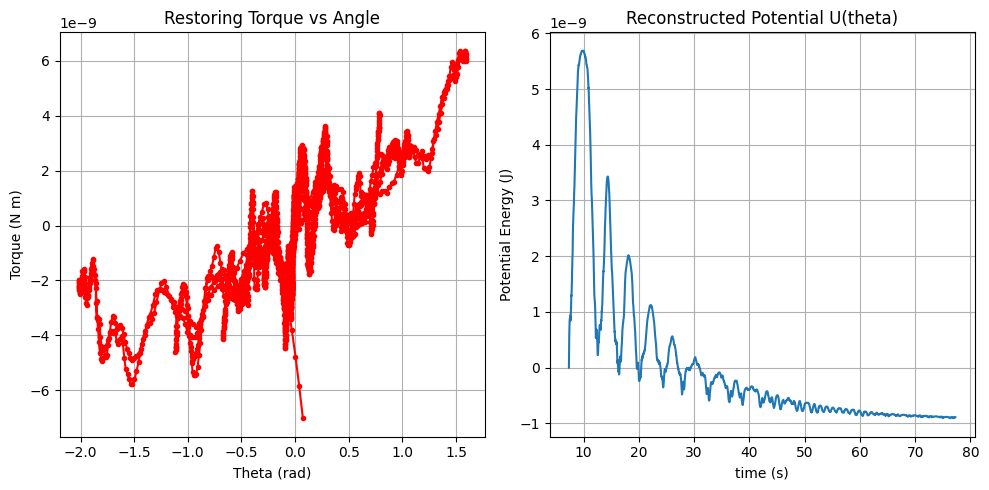

In [ ]:
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(thv, tau_total, 'r.-')
plt.title("Restoring Torque vs Angle")
plt.xlabel("Theta (rad)")
plt.ylabel("Torque (N m)")
plt.grid(True)
plt.subplot(1, 2, 2)
plt.plot(tv, U_theta, '-')
plt.title("Reconstructed Potential U(theta)")
plt.xlabel("time (s)")
plt.ylabel("Potential Energy (J)")
plt.grid(True)
plt.tight_layout()
#plt.savefig(".png", dpi=400, bbox_inches="tight")
plt.show()

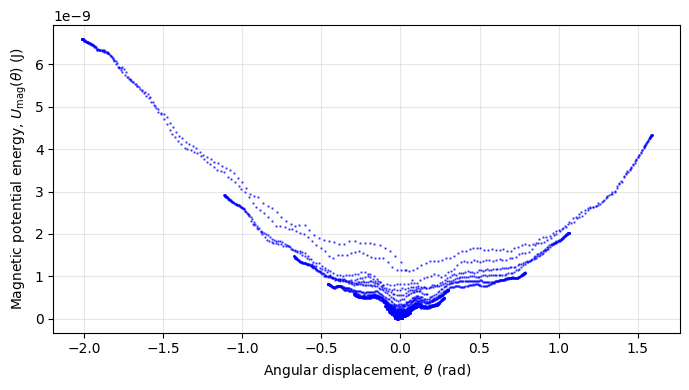

In [ ]:
# ── Paper method: step-by-step accumulation along trajectory ──
# tau_total_mid and d_theta are already time-ordered — no sorting needed

delta_U = tau_total_mid * d_theta
U_theta = np.cumsum(np.insert(delta_U, 0, 0))
U_theta_shifted = U_theta - np.min(U_theta)

# ── Plot U vs θ (time-ordered trajectory traces the landscape) ──
plt.figure(figsize=(7, 4))
plt.plot(thv, U_theta_shifted, 'b.', ms=1.5, alpha=0.6)
plt.xlabel(r'Angular displacement, $\theta$ (rad)')
plt.ylabel(r'Magnetic potential energy, $U_{\mathrm{mag}}(\theta)$ (J)')
#plt.title(r'Reconstructed magnetic potential $U_{\mathrm{mag}}(\theta)$ 'r'from the Dumont et al. method')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("Reconstructed Umag.png", dpi=400, bbox_inches="tight")
plt.show()

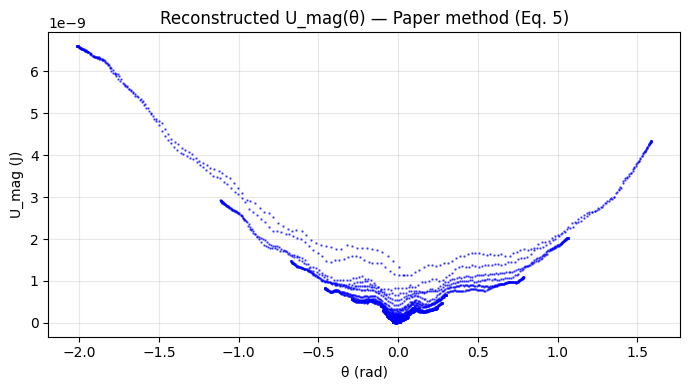

In [ ]:
plt.figure(figsize=(7, 4))
plt.plot(thv, U_theta_shifted, 'b.', ms=1.5, alpha=0.6)

plt.xlabel('θ (rad)')
plt.ylabel('U_mag (J)')
plt.title('Reconstructed U_mag(θ) — Paper method (Eq. 5)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

<>:23: SyntaxWarning: invalid escape sequence '\k'
<>:23: SyntaxWarning: invalid escape sequence '\k'
/tmp/ipykernel_17978/3829282679.py:23: SyntaxWarning: invalid escape sequence '\k'
  plt.plot(theta_theory, U_theory, 'r-', lw=1.5, label='Ideal Harmonic Potential ($U = \\frac{1}{2}\kappa\\theta^2$)')


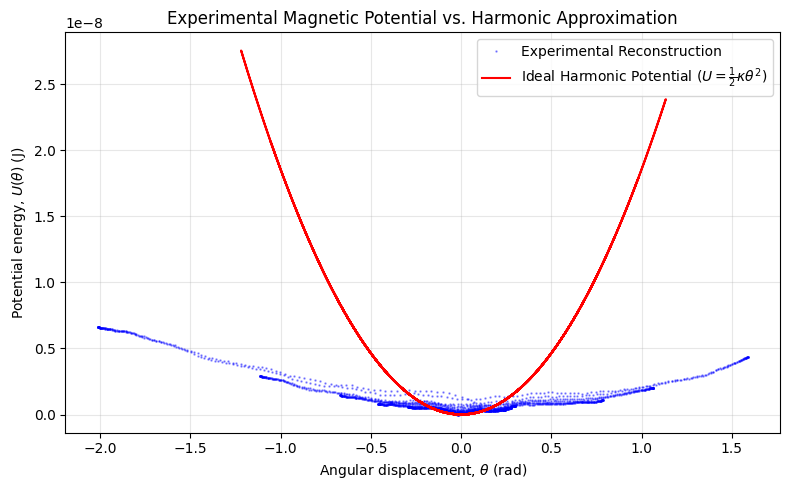

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

omega_0 = 2 * np.pi / T_avg
kappa = I * (omega_0)**2

decay_rate = gamma/(2*I)

#omega_0=np.sqrt(kappa/I)
omega_d=np.sqrt(omega_0**2 - decay_rate**2)
theta_theory_max = np.max(np.abs(thv))
theta_theory = theta_theory_max * np.exp(-decay_rate* tv) * np.cos(omega_d*tv)
# Calculate the perfect harmonic potential (U = 0.5 * k * theta^2)
U_theory = 0.5 * kappa * (theta_theory)**2

# --- 3. Plot Them Together ---
plt.figure(figsize=(8, 5))

# Plot the experimental "fuzzy" data (alpha=0.4 makes the dots slightly transparent)
plt.plot(thv, U_theta_shifted, 'b.', ms=1.5, alpha=0.4, label='Experimental Reconstruction')

# Plot the perfect theoretical parabola right on top
plt.plot(theta_theory, U_theory, 'r-', lw=1.5, label='Ideal Harmonic Potential ($U = \\frac{1}{2}\kappa\\theta^2$)')

# Formatting
plt.xlabel(r'Angular displacement, $\theta$ (rad)')
plt.ylabel(r'Potential energy, $U(\theta)$ (J)')
plt.title('Experimental Magnetic Potential vs. Harmonic Approximation')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("Umag Vs Harmonic.png", dpi=400, bbox_inches="tight")
plt.show()

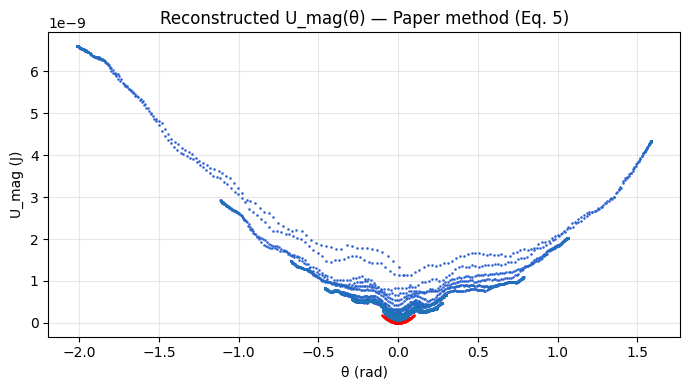

In [ ]:
plt.figure(figsize=(7, 4))
plt.plot(thv, U_theta_shifted, 'b.', ms=1.5, alpha=0.6)

theta_c = 0.5          # rad

theta_grid = np.linspace(-0.1, 0.1, 200)
U_mag_harmonic = 0.5 * kappa * theta_grid**2


plt.xlabel('θ (rad)')
plt.ylabel('U_mag (J)')
plt.title('Reconstructed U_mag(θ) — Paper method (Eq. 5)')
plt.plot(thv, U_theta_shifted, '.', ms=1.5, alpha=0.6)
plt.plot(theta_grid, U_mag_harmonic, 'r.', ms=1.5, alpha=0.6)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

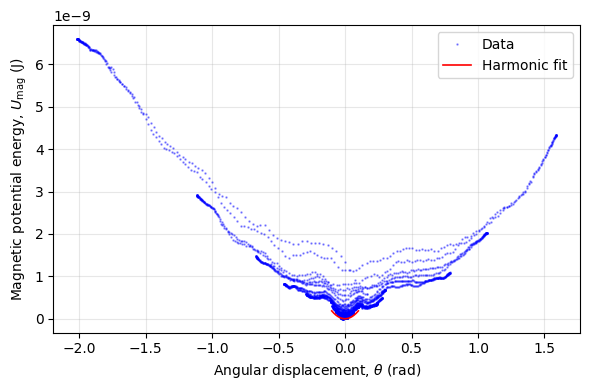

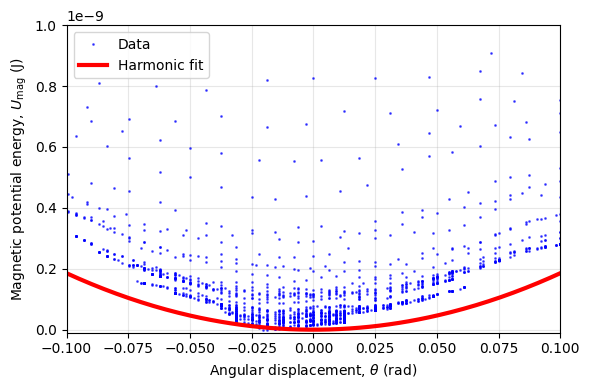

In [ ]:
# --- Figure 1: Full reconstruction ---
fig1, ax1 = plt.subplots(figsize=(6, 4))

ax1.plot(thv, U_theta_shifted, 'b.', ms=1.5, alpha=0.4, label='Data')
ax1.plot(theta_grid, U_mag_harmonic, 'r-', lw=1.2, label='Harmonic fit')

ax1.set_xlabel(r'Angular displacement, $\theta$ (rad)')
ax1.set_ylabel(r'Magnetic potential energy, $U_{\mathrm{mag}}$ (J)')
#ax1.set_title('Reconstructed magnetic potential: full angular range')
ax1.grid(True, alpha=0.3)
ax1.legend()

fig1.tight_layout()
fig1.savefig("Umag_full_range.png", dpi=400, bbox_inches="tight")
fig1.show()


# --- Figure 2: Zoomed harmonic potential ---
fig2, ax2 = plt.subplots(figsize=(6, 4))

ax2.plot(thv, U_theta_shifted, 'b.', ms=2, alpha=0.6, label='Data')
ax2.plot(theta_grid, U_mag_harmonic, 'r-', lw=3, label='Harmonic fit')

ax2.set_xlim(-0.1, 0.1)
ax2.set_ylim(-0.1e-10, 1e-9)

ax2.set_xlabel(r'Angular displacement, $\theta$ (rad)')
ax2.set_ylabel(r'Magnetic potential energy, $U_{\mathrm{mag}}$ (J)')
#ax2.set_title('Reconstructed magnetic potential: zoom around equilibrium')
ax2.grid(True, alpha=0.3)
ax2.legend()

fig2.tight_layout()
fig2.savefig("Umag_zoom_equilibrium.png", dpi=400, bbox_inches="tight")
fig2.show()

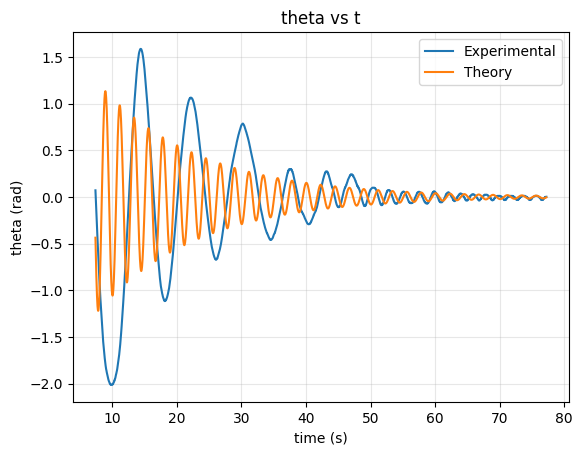

In [ ]:
from numpy.ma.core import exp
import matplotlib.pyplot as plt
import numpy as np

# --- 1. System Parameters ---
decay_rate = gamma/(2*I)

#omega_0=np.sqrt(kappa/I)
omega_d=np.sqrt(omega_0**2 - decay_rate**2)
#theta_theory = thv[0] * np.exp(-decay_rate* tv) * np.cos(omega_d*tv)
theta_theory_max = np.max(np.abs(thv))
theta_theory = theta_theory_max * np.exp(-decay_rate* tv) * np.cos(omega_d*tv)


# Formatting
plt.xlabel('time (s)')
plt.ylabel('theta (rad)')
plt.title('theta vs t')
plt.plot(tv, thv, label = "Experimental")
plt.plot(tv, theta_theory, label = "Theory")
plt.grid(True, alpha=0.3)
plt.legend(loc='upper right')
plt.savefig("my_plot.png", dpi=400, bbox_inches="tight")
plt.show()

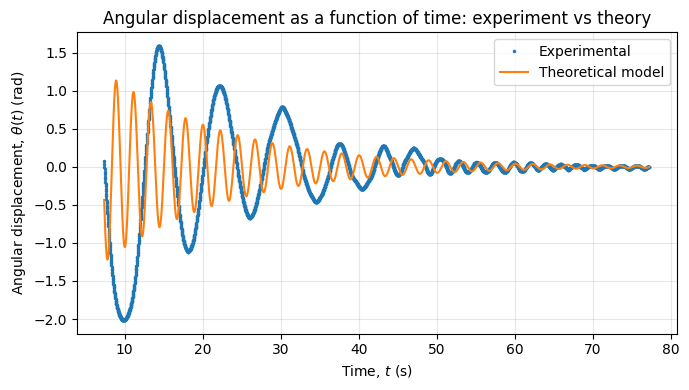

In [ ]:
# Example: window indices you actually plot
i0, i1 = 0, len(tv)          # or something like spiral_start:...
tv_window  = tv[i0:i1]
thv_window = thv[i0:i1]

theta_theory_max = np.max(np.abs(thv_window))
theta_theory = theta_theory_max * np.exp(-decay_rate * tv_window) * np.cos(omega_d * tv_window)


plt.figure(figsize=(7, 4))

plt.plot(tv, thv, '.', ms=3, label='Experimental')
plt.plot(tv, theta_theory, '-', lw=1.5, label='Theoretical model')

plt.xlabel(r'Time, $t$ (s)')
plt.ylabel(r'Angular displacement, $\theta(t)$ (rad)')
plt.title(r'Angular displacement as a function of time: experiment vs theory')
plt.grid(True, alpha=0.3)
plt.legend(loc='upper right')

plt.tight_layout()
plt.savefig('theta_vs_time_experiment_vs_theory.png',
            dpi=400, bbox_inches='tight')
plt.show()


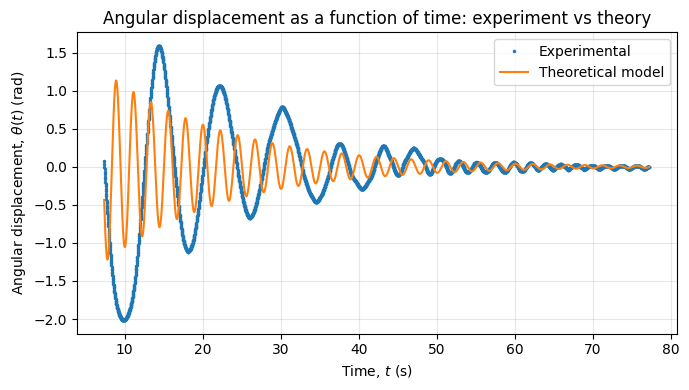

In [ ]:
plt.figure(figsize=(7, 4))

plt.plot(tv, thv, '.', ms=3, label='Experimental')
plt.plot(tv, theta_theory, '-', lw=1.5, label='Theoretical model')

plt.xlabel(r'Time, $t$ (s)')
plt.ylabel(r'Angular displacement, $\theta(t)$ (rad)')
plt.title(r'Angular displacement as a function of time: experiment vs theory')
plt.grid(True, alpha=0.3)
plt.legend(loc='upper right')

plt.tight_layout()
plt.savefig('theta_vs_time_experiment_vs_theory.png',
            dpi=400, bbox_inches='tight')
plt.show()

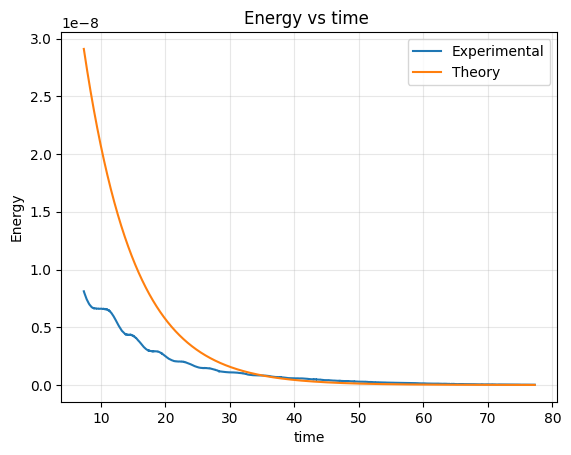

In [ ]:
omega_theory = np.gradient(theta_theory)
energy_0 = 0.5 * kappa * (theta_theory_max**2)

energy_theory = energy_0* np.exp(-2 * decay_rate*tv)

omega       = np.gradient(thv, tv)
omega_s     = savgol_filter(omega, window_length=21, polyorder=3)
energy_experimental = U_theta_shifted + 0.5*I*omega_s**2

# Formatting
plt.xlabel('time')
plt.ylabel('Energy')
plt.title('Energy vs time ')
plt.plot(tv, energy_experimental, label = "Experimental")
plt.plot(tv, energy_theory, label = "Theory")
plt.grid(True, alpha=0.3)
plt.legend(loc='upper right')
plt.show()


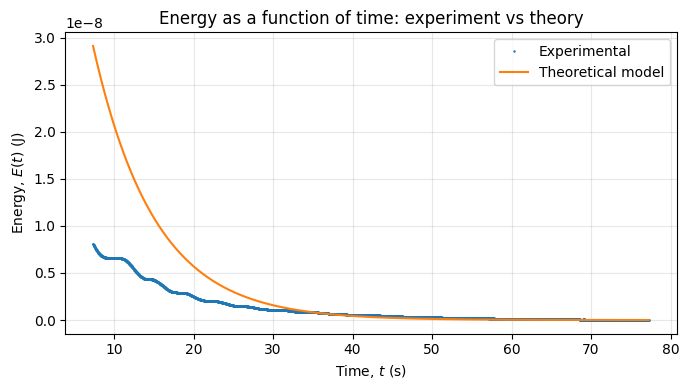

In [ ]:
plt.figure(figsize=(7, 4))

plt.plot(tv, energy_experimental, '.', ms=1.5, label='Experimental')
plt.plot(tv, energy_theory, '-', lw=1.5, label='Theoretical model')

plt.xlabel(r'Time, $t$ (s)')
plt.ylabel(r'Energy, $E(t)$ (J)')
plt.title(r'Energy as a function of time: experiment vs theory')
plt.grid(True, alpha=0.3)
plt.legend(loc='upper right')

plt.tight_layout()
plt.savefig('energy_vs_time_experiment_vs_theory.png',
            dpi=400, bbox_inches='tight')
plt.show()

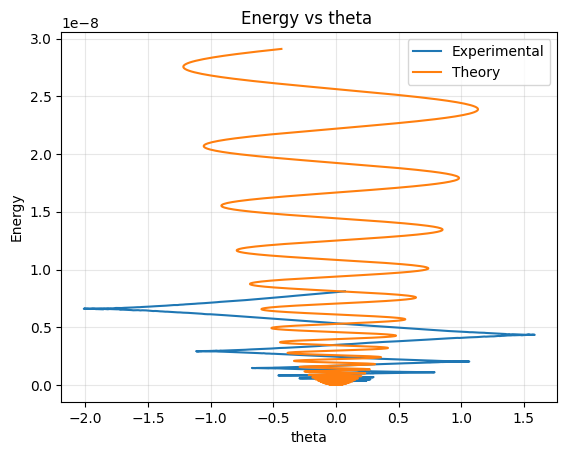

In [ ]:
# Formatting
plt.xlabel('theta')
plt.ylabel('Energy')
plt.title('Energy vs theta ')
plt.plot(thv, energy_experimental, label = "Experimental")
plt.plot(theta_theory, energy_theory, label = "Theory")
plt.grid(True, alpha=0.3)
plt.legend(loc='upper right')
plt.show()

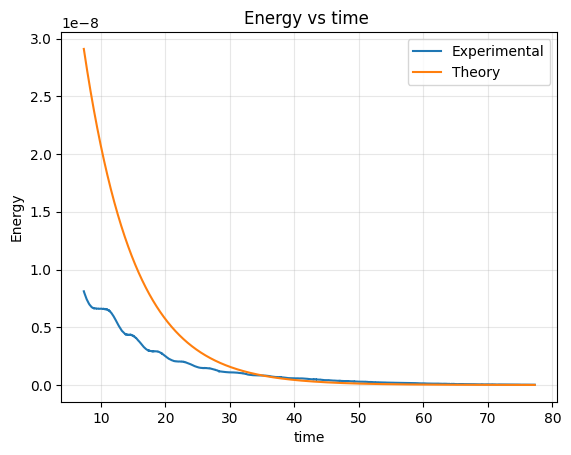

In [ ]:
plt.xlabel('time')
plt.ylabel('Energy')
plt.title('Energy vs time ')
plt.plot(tv, energy_experimental, label = "Experimental")
plt.plot(tv, energy_theory, label = "Theory")
plt.grid(True, alpha=0.3)
plt.legend(loc='upper right')
plt.show()

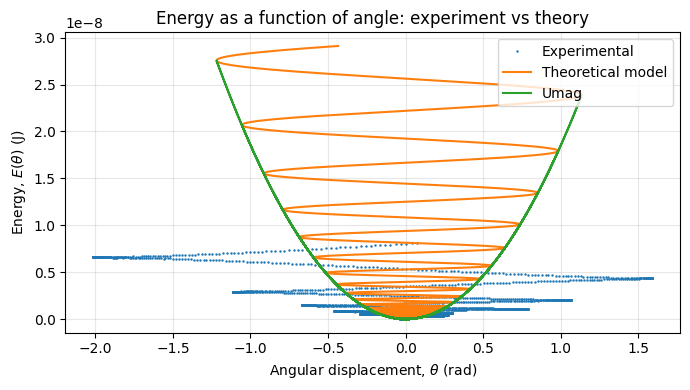

In [ ]:
plt.figure(figsize=(7, 4))

plt.plot(thv, energy_experimental, '.', ms=1.5, label='Experimental')
plt.plot(theta_theory, energy_theory, '-', lw=1.5, label='Theoretical model')
plt.plot(theta_theory, U_theory, '-', lw=1.5, label='Umag')

plt.xlabel(r'Angular displacement, $\theta$ (rad)')
plt.ylabel(r'Energy, $E(\theta)$ (J)')
plt.title(r'Energy as a function of angle: experiment vs theory')
plt.grid(True, alpha=0.3)
plt.legend(loc='upper right')

plt.tight_layout()
plt.savefig('energy_vs_angle_experiment_vs_theory.png',
            dpi=400, bbox_inches='tight')
plt.show()

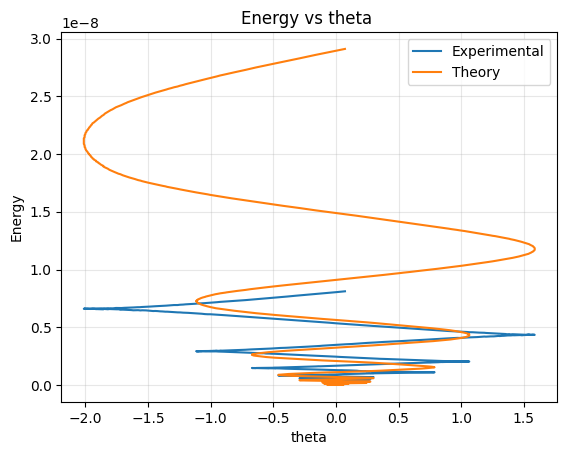

In [ ]:
plt.xlabel('theta')
plt.ylabel('Energy')
plt.title('Energy vs theta ')
plt.plot(thv, energy_experimental, label = "Experimental")
plt.plot(thv, energy_theory, label = "Theory")
plt.grid(True, alpha=0.3)
plt.legend(loc='upper right')
plt.show()

In [ ]:
import pandas as pd
from google.colab import files  # only works inside Colab

# 1. Put data into a DataFrame
df = pd.DataFrame({
    "t": t,
    "theta_theory": theta_theory,
})

# 2. Save to CSV in the Colab filesystem
df.to_csv("theta_theory_vs_t.csv", index=False)

# 3. Trigger download to your laptop
files.download("theta_theory_vs_t.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

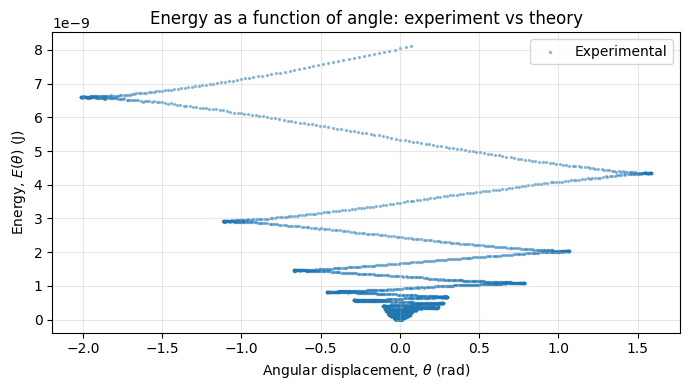

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# theta_exp, E_exp = your experimental data (1D numpy arrays)

# 1. Choose angle bins
n_bins = 50
theta_min, theta_max = thv.min(), thv.max()
bins = np.linspace(theta_min, theta_max, n_bins+1)

theta_env = []
E_env = []

# 2. For each bin, take the minimum energy (lower envelope)
for i in range(n_bins):
    mask = (thv >= bins[i]) & (thv < bins[i+1])
    if np.any(mask):
        theta_mid = 0.5 * (bins[i] + bins[i+1])
        E_min = np.min(energy_experimental[mask])
        theta_env.append(theta_mid)
        E_env.append(E_min)

theta_env = np.array(theta_env)
E_env = np.array(E_env)

# 3. Optionally smooth the envelope a bit
from scipy.ndimage import gaussian_filter1d
E_env_smooth = gaussian_filter1d(E_env, sigma=1)

# 4. Plot
plt.figure(figsize=(7,4))
#plt.plot(thv, energy_experimental,'r.', alpha=0.4, label="Experimental")
# or, if you really want size, switch to scatter:
plt.scatter(thv, energy_experimental, s=2, alpha=0.4, label="Experimental")
#plt.plot(theta_env, E_env_smooth, 'k-', lw=1.5, label="Experimental envelope")
plt.xlabel(r"Angular displacement, $\theta$ (rad)")
plt.ylabel(r"Energy, $E(\theta)$ (J)")

#plt.plot(theta_theory, energy_theory, '-', lw=1.5, label='Theoretical model')
#plt.plot(theta_theory, U_theory, 'g-', lw=1.5, label='Umag')

plt.title(r'Energy as a function of angle: experiment vs theory')
plt.grid(True, alpha=0.3)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

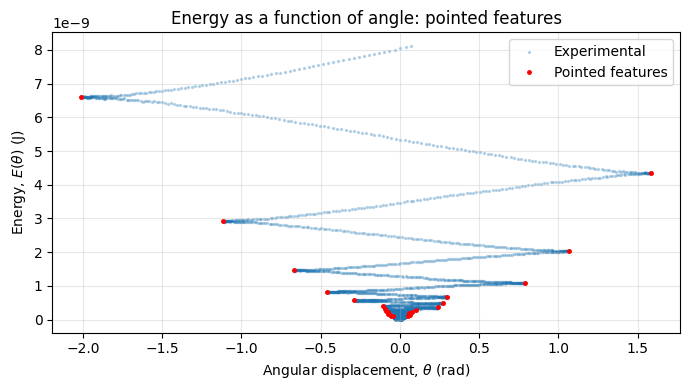

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

theta = thv
E = energy_experimental

# 1) Work with absolute theta to get tips on both sides
theta_abs = np.abs(theta)

# 2) Find local maxima of |theta|  (geometric pointed features)
#    TUNE distance and prominence until you get the cusps you see by eye
peaks, _ = find_peaks(
    theta_abs,
    distance=40,                       # minimum samples between cusps
    prominence=0.02 * theta_abs.max()  # keep only strong corners
)

theta_cusp = theta[peaks]
E_cusp = E[peaks]

# 3) Plot
plt.figure(figsize=(7,4))
plt.scatter(theta, E, s=2, alpha=0.25, label="Experimental")
plt.plot(theta_cusp, E_cusp, 'r.', ms=5, label="Pointed features")

# Optionally connect them in index order
#plt.plot(theta_cusp, E_cusp, 'r-', lw=1.5)

plt.xlabel(r"Angular displacement, $\theta$ (rad)")
plt.ylabel(r"Energy, $E(\theta)$ (J)")
plt.title(r'Energy as a function of angle: pointed features')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

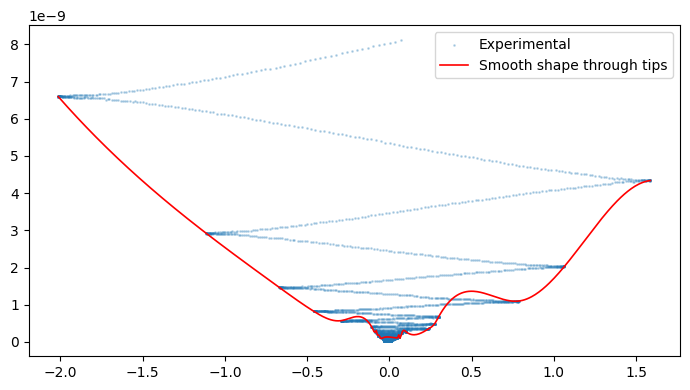

In [ ]:
from scipy.interpolate import UnivariateSpline

# sort by theta so the shape is left→right
order = np.argsort(theta_cusp)
theta_fit = theta_cusp[order]
E_fit = E_cusp[order]

spline = UnivariateSpline(theta_fit, E_fit, s=0)  # or small s for smoothing
theta_smooth = np.linspace(theta_fit.min(), theta_fit.max(), 500)
E_smooth = spline(theta_smooth)

plt.figure(figsize=(7,4))
plt.scatter(thv, E, s=1, alpha=0.25, label="Experimental")
plt.plot(theta_smooth, E_smooth, 'r-', lw=1.2, label="Smooth shape through tips")
plt.legend()
plt.tight_layout()
plt.show()

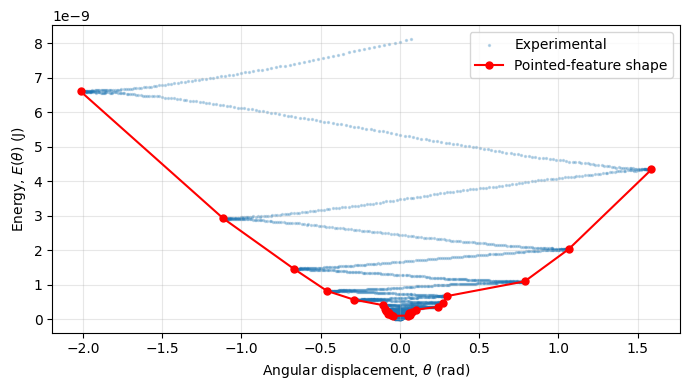

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

theta = thv
E = energy_experimental

# pointed features = local maxima of |theta|
theta_abs = np.abs(theta)
peaks, _ = find_peaks(theta_abs, distance=40, prominence=0.02 * theta_abs.max())

theta_cusp = theta[peaks]
E_cusp = E[peaks]

# sort left to right
order = np.argsort(theta_cusp)
theta_cusp = theta_cusp[order]
E_cusp = E_cusp[order]

plt.figure(figsize=(7,4))
plt.scatter(theta, E, s=2, alpha=0.25, label="Experimental")
plt.plot(theta_cusp, E_cusp, 'ro-', lw=1.5, ms=5, label="Pointed-feature shape")

plt.xlabel(r"Angular displacement, $\theta$ (rad)")
plt.ylabel(r"Energy, $E(\theta)$ (J)")
#plt.title(r'Energy as a function of angle: pointed features')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('pointed feature shape_Mar 6.png', dpi=400, bbox_inches='tight')
plt.show()

In [ ]:
import os

os.listdir()  # or: os.listdir('/content')

['.config',
 'energy_vs_time_experiment_vs_theory.png',
 'restoring_torque_vs_time.png',
 'Alpha(t) vs theta.png',
 'signal_diagnostic.png',
 'my_plot.png',
 'restoring_torque_vs_angle.png',
 'damping_extraction_summary.png',
 'reconstructed_potential_vs_angle.png',
 'pointed feature shape_Mar 6.png',
 'tracking_output_6.csv',
 'damping_log_linear_check.png',
 'Reconstructed Umag.png',
 'energy_vs_angle_experiment_vs_theory.png',
 'theta_theory_vs_t.csv',
 'damping_envelope_decay_fit.png',
 'damping_cleaned_signal_with_peaks.png',
 'theta_vs_time_experiment_vs_theory.png',
 'Umag Vs Harmonic.png',
 'reconstructed_potential_vs_time.png',
 'sample_data']

In [ ]:
from google.colab import files
files.download('pointed feature shape_Mar 6.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>